In [59]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from reportlab.lib import colors
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import ParagraphStyle
from reportlab.platypus import SimpleDocTemplate, Paragraph, Table, TableStyle, Spacer, Image
from reportlab.lib.colors import HexColor
import matplotlib.patches as patches
from natsort import natsorted



In [60]:
def parse_sample_df(fname):
    df = pd.read_csv(fname)
    df.rename({'Experiment': 'plate'}, axis=1, inplace=True)

    # add multiplexed genotypes if relevant
    g_cols = ['mult_genotype_1', 'mult_genotype_2']
    df[g_cols] = df.Genotype.str.split('/', expand=True)

    # adjust single-genotype wells
    df.loc[df.well_type=='Single', g_cols] = np.nan

    # add a multiplexed genotype column
    inds = df.loc[df.well_type=='Multiplexed'].index
    # df['mult_genotype'] = '' # maybe change to this but needs to be tested
    df['mult_genotype'] = np.nan
    df.loc[inds, 'mult_genotype'] = df.loc[inds, g_cols[0]].astype(str)+'_'+\
                                   df.loc[inds, g_cols[1]].astype(str)

    # checks
    for g in g_cols:
        assert len(df.loc[(df.well_type=='Single')&(df[g].notnull())].index) == 0

    return df

In [61]:
config = pd.read_csv('/dfs9/seyedam-lab/erebboah/parse_pipeline/configs/igvf_b01_config.tsv', sep='\t')


In [62]:
plate = config['plate'][0]

In [63]:
sample_df = parse_sample_df('/dfs9/seyedam-lab/erebboah/parse_pipeline/configs/sample_metadata.csv')
sample_df = sample_df[sample_df['plate'] == plate]

In [64]:
kit = 'WT'  
chemistry = 'v2'
subpools = config['subpool'].unique().tolist()

In [65]:
sample_df['Genotype'].unique().tolist()

['B6J', 'CASTJ']

# Broad overview

# Plate map

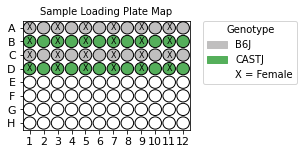

In [66]:
df = sample_df
rows = list('ABCDEFGH')
columns = range(1, 13)

if sample_df['Tissue'].nunique() > sample_df['Genotype'].nunique():
    color_by = 'Tissue'
else:
    color_by = 'Genotype'


# Dictionaries for color mapping
geno_dict = {
    #'129S1J': '#DA9CC1',  
    #'AJ': '#F4C245',             
    'B6J': '#C0BFBF',               
    'CASTJ': '#55AF5B',  
    #'NODJ': '#4F6EAF',        
    #'NZOJ': '#52A5DB',              
    #'PWKJ': '#D83026',        
    #'WSBJ': '#683C91'   
}

tissue_dict = {
    'CortexHippocampus': '#F8C471',  
    'Heart': '#AF7AC5',             
    'Liver': '#F15922',               
    'HypothalamusPituitary': '#27AE60',  
    'Adrenal': '#8B4513',        
    'Kidney': '#CF1E1A',              
    'Gastrocnemius': '#FF69B4',        
    'GonadsFemale': '#2FE3E5',       
    'GonadsMale': '#00B7B8'     
}

# Determine which column to use for coloring
color_column = 'Genotype' if sample_df['Genotype'].nunique() >= sample_df['Tissue'].nunique() else 'Tissue'
color_dict = geno_dict if color_column == 'Genotype' else tissue_dict

# Create a color map for existing values and use white for NA
color_map = {id: color_dict.get(id, 'white') for id in df[color_column].unique()}
default_color = 'white'

# Create the plot
fig, ax = plt.subplots(figsize=(3, 2))

# Plot each well as a circle and add "X" for Female samples
for row_label in rows:
    for col_num in columns:
        well_data = df[(df['Row'] == row_label) & (df['Column'] == col_num)]
        if not well_data.empty:
            well_color = color_map[well_data[color_by].values[0]]
            sex = well_data['Sex'].values[0]
        else:
            well_color = default_color
            sex = None
        ax.add_patch(plt.Circle((col_num, rows.index(row_label) + 1), 0.45, color=well_color, ec='black', linewidth=1))

        # Add "X" for wells with Female samples
        if sex == 'Female':
            ax.text(col_num, rows.index(row_label) + 1, 'X', color='black', ha='center', va='center', fontsize=8)

# Set the limits and labels
ax.set_xlim(0.5, 12.5)
ax.set_ylim(0.5, 8.5)
ax.set_xticks(columns)
ax.set_yticks(range(1, 9))
ax.set_yticklabels(rows, fontsize=11)
ax.set_xticklabels(columns, fontsize=11)

# Add labels and title
ax.set_title(f'Sample Loading Plate Map', fontsize=10)

plt.gca().invert_yaxis()  # Invert y-axis to match typical well plate layout


# Create legend
handles = [patches.Patch(color=color_dict[key], label=key) for key in color_dict]
handles.append(patches.Patch(color='white', label='X = Female'))

ax.legend(handles=handles, bbox_to_anchor=(1.05, 1.05), loc='upper left', fontsize=10, title=color_column)


plt.show()

# Save the plot as a PNG file
plate_map = "plate_map_plot.png"
fig.savefig(plate_map, format='png', bbox_inches='tight', dpi=300)


In [67]:
acc_map = pd.read_csv("/dfs9/seyedam-lab/erebboah/parse_pipeline/ref/IGVF_B01_map.tsv", sep = "\t")


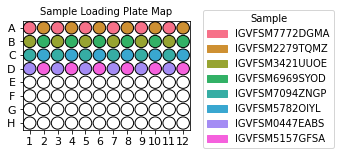

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Generate a unique color palette for samples
unique_samples = acc_map['sample'].unique()
palette = sns.color_palette("husl", len(unique_samples))
sample_dict = dict(zip(unique_samples, palette))

# Create a color map for each unique sample
color_map = {sample: sample_dict[sample] for sample in unique_samples}
default_color = 'white'

# Plate layout
rows = list('ABCDEFGH')
columns = range(1, 13)

# Create the plot
fig, ax = plt.subplots(figsize=(3, 2))

# Plot each well as a circle colored by sample
for row_label in rows:
    for col_num in columns:
        well_data = acc_map[acc_map['well'] == f"{row_label}{col_num}"]
        if not well_data.empty:
            well_color = color_map[well_data['sample'].values[0]]
        else:
            well_color = default_color
        ax.add_patch(plt.Circle((col_num, rows.index(row_label) + 1), 0.45, color=well_color, ec='black', linewidth=1))

# Set the limits and labels
ax.set_xlim(0.5, 12.5)
ax.set_ylim(0.5, 8.5)
ax.set_xticks(columns)
ax.set_yticks(range(1, 9))
ax.set_yticklabels(rows, fontsize=11)
ax.set_xticklabels(columns, fontsize=11)

# Add labels and title
ax.set_title('Sample Loading Plate Map', fontsize=10)

plt.gca().invert_yaxis()  # Invert y-axis to match typical well plate layout

# Create legend
handles = [patches.Patch(color=color_map[sample], label=sample) for sample in unique_samples]
ax.legend(handles=handles, bbox_to_anchor=(1.05, 1.15), loc='upper left', fontsize=10, title='Sample')

plt.show()

# Save the plot as a PNG file
sample_plate_map = "sample_plate_map.png"
fig.savefig(sample_plate_map, format='png', bbox_inches='tight', dpi=300)


# Subpool tables

In [69]:
reports = []

for subpool in subpools:
    file_path = f"/dfs9/seyedam-lab/erebboah/parse_pipeline/pipeline_report/igvf_b01/{subpool}/report.csv"
    df = pd.read_csv(file_path)
    
    # Select the relevant columns
    df_selected = df[['Subpool','Total reads', 'Total UMIs', 'Sequencing saturation', 
                      'Total pseudoaligned', 'Pct. pseudoaligned']].copy()
    df_selected = df_selected.rename(columns={'Sequencing saturation': 'Fraction duplicated UMIs'})

    
    # Append the selected data to the reports list
    reports.append(df_selected)

align_reports = pd.concat(reports, ignore_index=True)



In [70]:
reports = []

for subpool in subpools:
    # Define the file path
    file_path = f"/dfs9/seyedam-lab/erebboah/parse_pipeline/pipeline_report/igvf_b01/{subpool}/report.csv"
    
    df = pd.read_csv(file_path)
    
    df_selected = df[['Subpool','Num. cells >= 200 UMI', 'Median UMIs/cell (200 UMIs)', 
                      'Mean UMIs/cell (200 UMIs)', 'Median genes/cell (200 UMIs)', 
                      'Mean genes/cell (200 UMIs)']].copy()
    
    # Rename the columns
    qc_200umi = df_selected.rename(columns={
        'Num. cells >= 200 UMI': 'Number of cells',
        'Median UMIs/cell (200 UMIs)': 'Median UMIs/cell',
        'Mean UMIs/cell (200 UMIs)': 'Mean UMIs/cell',
        'Median genes/cell (200 UMIs)': 'Median genes/cell',
        'Mean genes/cell (200 UMIs)': 'Mean genes/cell'
    })
    
    # Append the renamed dataframe to the reports list
    reports.append(qc_200umi)

# Combine all the dataframes in the reports list into a single dataframe
qc_200umi = pd.concat(reports, ignore_index=True)


In [71]:
reports = []

for subpool in subpools:
    # Define the file path
    file_path = f"/dfs9/seyedam-lab/erebboah/parse_pipeline/pipeline_report/igvf_b01/{subpool}/report.csv"
    
    df = pd.read_csv(file_path)
    
    df_selected = df[['Subpool','Num. cells >= 500 UMI', 'Median UMIs/cell (500 UMIs)', 
                      'Mean UMIs/cell (500 UMIs)', 'Median genes/cell (500 UMIs)', 
                      'Mean genes/cell (500 UMIs)']].copy()
    
    # Rename the columns
    qc_500umi = df_selected.rename(columns={
        'Num. cells >= 500 UMI': 'Number of cells',
        'Median UMIs/cell (500 UMIs)': 'Median UMIs/cell',
        'Mean UMIs/cell (500 UMIs)': 'Mean UMIs/cell',
        'Median genes/cell (500 UMIs)': 'Median genes/cell',
        'Mean genes/cell (500 UMIs)': 'Mean genes/cell'
    })
    
    # Append the renamed dataframe to the reports list
    reports.append(qc_500umi)

# Combine all the dataframes in the reports list into a single dataframe
qc_500umi = pd.concat(reports, ignore_index=True)


In [72]:
cells_200umi_sum = sum(int(read.replace(',', '')) for read in qc_200umi['Number of cells'])
formatted_cells_200umi_sum = format(cells_200umi_sum, ',')

cells_500umi_sum = sum(int(read.replace(',', '')) for read in qc_500umi['Number of cells'])
formatted_cells_500umi_sum = format(cells_500umi_sum, ',')


In [73]:
formatted_cells_500umi_sum

'126,250'

In [74]:
total_reads_sum = sum(int(read.replace(',', '')) for read in align_reports['Total reads'])
formatted_total_reads_sum = format(total_reads_sum, ',')


# Subpool level plots

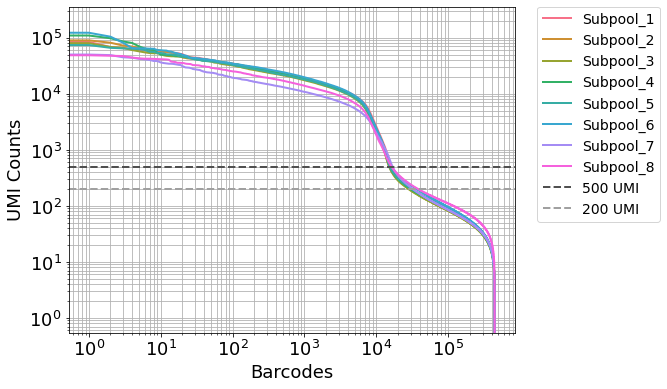

In [75]:
fig, ax = plt.subplots(figsize=(8, 6))


colors = sns.color_palette("husl", len(subpools))

fontsize = 18

# Loop through each subpool and plot the knee plot
for i, subpool in enumerate(subpools):
    knee_df = pd.read_csv(f'/dfs9/seyedam-lab/erebboah/parse_pipeline/pipeline_report/igvf_b01/{subpool}/knee_plot_df.csv')
    
    # Extract the UMI counts
    knee = knee_df['UMIs'].values
    
    # Plot the data
    ax.loglog(range(len(knee)), knee, linewidth=2, color=colors[i], label=subpool)

# Add labels and formatting
ax.set_ylabel("UMI Counts", fontsize=fontsize)
ax.set_xlabel("Barcodes", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)

# Add horizontal lines for 500 UMI and 200 UMI
ax.axhline(y=500, linewidth=2, color="#505050", linestyle='--', label='500 UMI')
ax.axhline(y=200, linewidth=2, color="#A0A0A0", linestyle='--', label='200 UMI')

# Enable grid
plt.grid(True, which="both")

ax.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Save the plot as a PNG file
subpool_knee = "raw_counts_subpool_knee_plot_plate.png"
plt.savefig(subpool_knee, format='png', bbox_inches='tight', dpi=300)

# Show the plot
plt.show()


## subpool level plate hmap

In [76]:
adata = sc.read_h5ad(f'../igvf_b01/LeftCortex/adata.h5ad')


In [77]:
def create_round_heatmap(adata, well_column, kit):
    # Count the number of cells per well
    well_counts = adata.obs[well_column].value_counts().sort_index()

    # Convert the well counts to a DataFrame for easier manipulation
    well_counts_df = well_counts.reset_index()
    well_counts_df.columns = ['well', 'cell_count']

    # Create an empty DataFrame for the 96-well plate
    rows = list('ABCDEFGH')
    cols = list(range(1, 13))
    plate_df = pd.DataFrame(0, index=rows, columns=cols)

    # Fill the plate_df with the cell counts
    for _, row in well_counts_df.iterrows():
        well = row['well']
        cell_count = row['cell_count']
        plate_df.at[well[0], int(well[1:])] = cell_count

    # Determine the round number
    round_number = well_column[2]

    # If kit is "WT" and it's round 1, only use rows A-D
    if kit == "WT" and round_number == "1":
        plate_df = plate_df.loc['A':'D']

    # Create a heatmap
    plt.figure(figsize=(10, 5))
    
    sns.heatmap(plate_df, annot=True, fmt='d', cmap='Reds', cbar=True, linewidths=0, 
                annot_kws={"size": 12}, cbar_kws={'label': 'Cell Count'}, vmin=0, vmax=plate_df.max().max()*1.2)
    
    plt.title(f'Round {round_number} - cells per well (>=500 UMI)', fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(rotation=0, fontsize=16)
    
    # Save the plot as a PNG file
    hmap = f"round_{well_column}_plate_hmap_all_subs.png"
    plt.savefig(hmap, format='png', bbox_inches='tight', dpi=300)

    plt.show()


In [78]:
sc.pp.filter_cells(adata, min_counts = 500) # UMI cutoff



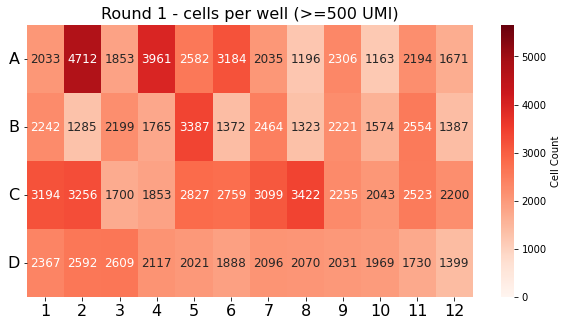

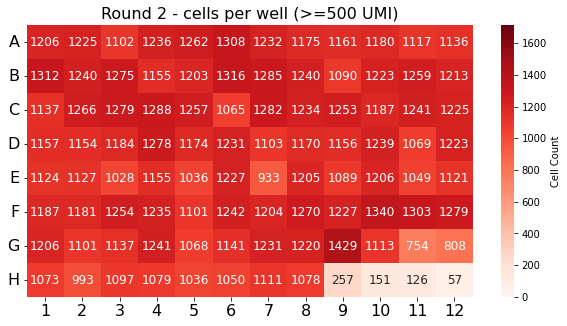

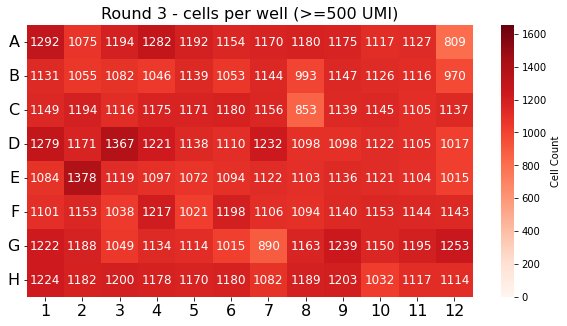

In [79]:
for well_column in ['bc1_well', 'bc2_well', 'bc3_well']:
    create_round_heatmap(adata, well_column, kit)

# Final adata plots

In [80]:
cb_settings = pd.read_csv(f"/dfs9/seyedam-lab/erebboah/parse_pipeline/pipeline_report/igvf_b01/{subpool}/cellbender_settings.csv")
#cb_settings = cb_settings[cb_settings['subpool'] == subpool]
#cb_settings = cb_settings.drop(columns=['subpool'])
cb_settings = cb_settings.drop(columns=['plate'])


In [81]:
cb_settings

,subpool,droplets_included
0,Subpool_1,40000
1,Subpool_2,40000
2,Subpool_3,40000
3,Subpool_4,40000
4,Subpool_5,40000
5,Subpool_6,40000
6,Subpool_7,40000
7,Subpool_8,40000


In [82]:
import pandas as pd

# List to store the results for each subpool
all_cb_results = []

# Loop through each subpool
for subpool in subpools:
    # Read the CSV file for the current subpool
    cb_metrics = pd.read_csv(f"/dfs5/bio/erebboah/parse_pipeline/pipeline_output_cellbender/igvf_b01/{subpool}/adata_denoised_metrics.csv", header=None)
    
    # Extract the required metrics by name
    selected_metrics = cb_metrics[cb_metrics[0].isin([
        'fraction_counts_removed_from_cells',
        'found_cells',
        'output_average_counts_per_cell',
    ])].copy()
    
    # Convert fraction_counts_removed_from_cells to a percentage
    selected_metrics.loc[selected_metrics[0] == 'fraction_counts_removed_from_cells', 1] *= 100
    
    # Rename the metrics
    selected_metrics[0] = selected_metrics[0].replace({
        'fraction_counts_removed_from_cells': 'Percent counts removed',
        'found_cells': 'Found cells',
        'output_average_counts_per_cell': 'Mean denoised counts/cell',
    })
    
    # Convert found_cells and output_average_counts_per_cell to formatted strings
    selected_metrics.loc[selected_metrics[0] == 'Found cells', 1] = selected_metrics.loc[selected_metrics[0] == 'Found cells', 1].apply(lambda x: f"{int(x):,}")
    selected_metrics.loc[selected_metrics[0] == 'Mean denoised counts/cell', 1] = selected_metrics.loc[selected_metrics[0] == 'Mean denoised counts/cell', 1].apply(lambda x: f"{x:,.1f}")
    selected_metrics.loc[selected_metrics[0] == 'Percent counts removed', 1] = selected_metrics.loc[selected_metrics[0] == 'Percent counts removed', 1].apply(lambda x: f"{x:,.1f}")
    
    # Transpose the DataFrame to have metrics as columns and a single row of values
    cb_results = selected_metrics.set_index(0).T
    
    # Add a column to indicate the subpool
    cb_results['Subpool'] = subpool
    
    # Append the result to the list
    all_cb_results.append(cb_results)

# Combine all results into a single DataFrame
final_cb_results = pd.concat(all_cb_results, ignore_index=True)

final_cb_results = final_cb_results[['Subpool', 'Percent counts removed', 'Found cells', 'Mean denoised counts/cell']]



In [83]:
adata = sc.read_h5ad(f'../igvf_b01/LeftCortex/adata.h5ad')


In [84]:
def plot_knee(adata, category_column='subpool'):
    unique_categories = natsorted(adata.obs[category_column].unique())

    fig, ax = plt.subplots(figsize=(8, 6))

    for category in unique_categories:
        # Subset the data for each sublibrary
        subset = adata[adata.obs[category_column] == category]

        # Calculate knee and num_cells for raw_counts
        knee_raw = np.sort(np.array(subset.layers['raw_counts'].sum(axis=1)).flatten())[::-1]
        cell_set_raw = np.arange(len(knee_raw))

        # Plot the knee for raw_counts
        ax.loglog(cell_set_raw, knee_raw, linewidth=3 ,label=f"{category} (raw)")

        # Calculate knee and num_cells for cellbender_counts
        knee_cellbender = np.sort(np.array(subset.layers['cellbender_counts'].sum(axis=1)).flatten())[::-1]
        cell_set_cellbender = np.arange(len(knee_cellbender))

        # Plot the knee for cellbender_counts
        ax.loglog(cell_set_cellbender, knee_cellbender, linewidth=3, label=f"{category} (cellbender)")

    # Plot the threshold line
    ax.axhline(y=500, linewidth=2, color="#505050", linestyle='--', label='500 UMI')
    ax.axhline(y=200, linewidth=2, color="#A0A0A0", linestyle='--', label='200 UMI')

    # Set labels and title
    ax.set_ylabel("UMI Counts", fontsize=18)
    ax.set_xlabel("Set of Barcodes", fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    ax.legend(fontsize=11, bbox_to_anchor=(1.02, 1.02), loc='upper left', title_fontsize = 11)

    # Customize tick parameters
    ax.tick_params(axis='both', which='major', labelsize=16)

    # Enable grid
    plt.grid(True, which="both")


def conditional_plot_knee(adata):
    # Check number of unique categories in 'Tissue'
    if len(adata.obs['Tissue'].unique()) > 5:
        category_column = "plate"
    else:
        category_column = "Tissue"
    
    # Plot using the determined category_column
    plot_knee(adata, category_column)
    



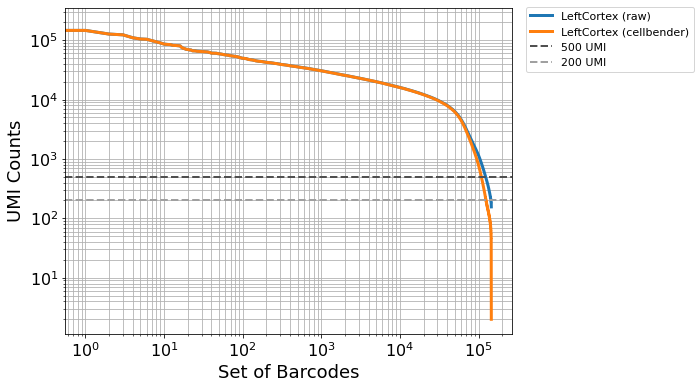

In [85]:
# Example usage
conditional_plot_knee(adata)

# Save the plot
cb_knee = "cb_knee_plot_plate.png"
plt.savefig(cb_knee, format='png', bbox_inches='tight', dpi=300)


In [86]:
adata.var_names = adata.var['gene_name']
adata.var['mt'] = adata.var_names.str.startswith('mt-')  # annotate the group of mitochondrial genes as 'mt'


In [87]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], layer = 'raw_counts', percent_top=None, log1p=False, inplace=True)
adata.obs.rename(columns={
    'n_genes_by_counts': 'n_genes_by_counts_raw_counts',
    'total_counts': 'total_counts_raw_counts',
    'total_counts_mt': 'total_counts_mt_raw_counts',
    'pct_counts_mt': 'pct_counts_mt_raw_counts'
}, inplace=True)

In [88]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], layer = 'cellbender_counts', percent_top=None, log1p=False, inplace=True)
adata.obs.rename(columns={
    'n_genes_by_counts': 'n_genes_by_counts_cb_counts',
    'total_counts': 'total_counts_cb_counts',
    'total_counts_mt': 'total_counts_mt_cb_counts',
    'pct_counts_mt': 'pct_counts_mt_cb_counts'
}, inplace=True)

In [89]:
import numpy as np

# Ensure there are no zero or negative values to avoid issues with log10 transformation
adata.obs['log10_n_genes_by_counts_raw_counts'] = np.log10(adata.obs['n_genes_by_counts_raw_counts'] + 1)
adata.obs['log10_total_counts_raw_counts'] = np.log10(adata.obs['total_counts_raw_counts'] + 1)

import numpy as np

# Ensure there are no zero or negative values to avoid issues with log10 transformation
adata.obs['log10_n_genes_by_counts_cb_counts'] = np.log10(adata.obs['n_genes_by_counts_cb_counts'] + 1)
adata.obs['log10_total_counts_cb_counts'] = np.log10(adata.obs['total_counts_cb_counts'] + 1)


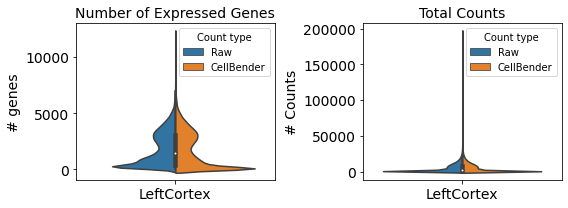

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assume adata.obs is the DataFrame you are working with
obs_data = adata.obs

if len(adata.obs['Tissue'].unique()) > 5:
    plot_category = "plate"
else:
    plot_category = "Tissue"
    

data_ngb = pd.melt(obs_data, id_vars=[plot_category], 
                   value_vars=['n_genes_by_counts_raw_counts', 'n_genes_by_counts_cb_counts'], 
                   var_name='Count type', value_name='counts')
data_ngb['Count type'] = data_ngb['Count type'].replace({
    'n_genes_by_counts_raw_counts': 'Raw',
    'n_genes_by_counts_cb_counts': 'CellBender'
})

data_tbc = pd.melt(obs_data, id_vars=[plot_category], 
                   value_vars=['total_counts_raw_counts', 'total_counts_cb_counts'], 
                   var_name='Count type', value_name='counts')
data_tbc['Count type'] = data_tbc['Count type'].replace({
    'total_counts_raw_counts': 'Raw',
    'total_counts_cb_counts': 'CellBender'
})


# Create the plots with independent y-axes
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=False)


size = 14

sns.violinplot(x=plot_category, y='counts', hue='Count type', data=data_ngb, split=True, ax=axes[0])
axes[0].set_title('Number of Expressed Genes', fontsize = size)
axes[0].set_ylabel('# genes', fontsize = size)
axes[0].set_xlabel("", fontsize = size)
axes[0].tick_params(axis='both', which='major', labelsize=size)

sns.violinplot(x=plot_category, y='counts', hue='Count type', data=data_tbc, split=True, ax=axes[1])
axes[1].set_title('Total Counts', fontsize = size)
axes[1].set_xlabel("", fontsize = size)
axes[1].set_ylabel('# Counts', fontsize = size)
axes[1].tick_params(axis='both', which='major', labelsize=size)

# Adjust layout
plt.tight_layout()



# Save the plot
qc_violin_genes_counts = "qc_violin_plot1_plate.png"
plt.savefig(qc_violin_genes_counts, format='png', bbox_inches='tight', dpi=300)

plt.show()

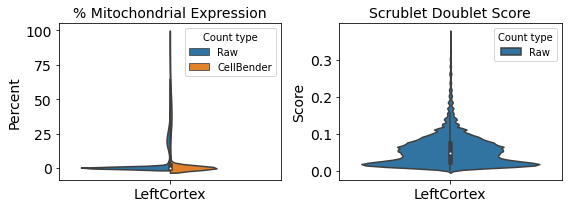

In [91]:

data_pmt = pd.melt(obs_data, id_vars=[plot_category], 
                   value_vars=['pct_counts_mt_raw_counts', 'pct_counts_mt_cb_counts'], 
                   var_name='Count type', value_name='Percent')
data_pmt['Count type'] = data_pmt['Count type'].replace({
    'pct_counts_mt_raw_counts': 'Raw',
    'pct_counts_mt_cb_counts': 'CellBender'
})


data_ds = pd.melt(obs_data, id_vars=[plot_category], 
                  value_vars=['doublet_score'], 
                  var_name='Count type', value_name='Score')
data_ds['Count type'] = data_ds['Count type'].replace({
    'doublet_score': 'Doublet Score'
})



    
# Create the plots with independent y-axes
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=False)


size = 14

sns.violinplot(x=plot_category, y='Percent', hue='Count type', data=data_pmt, split=True, ax=axes[0])
axes[0].set_title('% Mitochondrial Expression', fontsize = size)
axes[0].set_ylabel('Percent', fontsize = size)
axes[0].set_xlabel("", fontsize = size)
axes[0].tick_params(axis='both', which='major', labelsize=size)

sns.violinplot(x=plot_category, y='Score', data=data_ds, ax=axes[1])
axes[1].set_title('Scrublet Doublet Score', fontsize = size)
axes[1].set_ylabel('Score', fontsize = size)
axes[1].set_xlabel("", fontsize = size)
axes[1].tick_params(axis='both', which='major', labelsize=size)
axes[1].legend(title='Count type', labels=['Raw'])

# Adjust layout
plt.tight_layout()



# Save the plot
qc_violin_mt_ds = "qc_violin_plot2_plate.png"
plt.savefig(qc_violin_mt_ds, format='png', bbox_inches='tight', dpi=300)

plt.show()

In [92]:
adata = sc.read_h5ad('IGVFB01_LeftCortex_annotated_adata.h5ad')


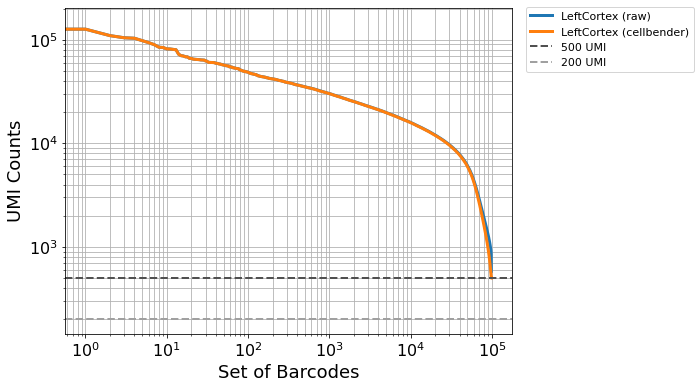

In [93]:
# Example usage
conditional_plot_knee(adata)

# Save the plot
cb_knee_filt = "cb_knee_plot_plate_filtered.png"
plt.savefig(cb_knee_filt, format='png', bbox_inches='tight', dpi=300)



In [94]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], layer = 'raw_counts', percent_top=None, log1p=False, inplace=True)
adata.obs.rename(columns={
    'n_genes_by_counts': 'n_genes_by_counts_raw_counts',
    'total_counts': 'total_counts_raw_counts',
    'total_counts_mt': 'total_counts_mt_raw_counts',
    'pct_counts_mt': 'pct_counts_mt_raw_counts'
}, inplace=True)

In [95]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], layer = 'cellbender_counts', percent_top=None, log1p=False, inplace=True)
adata.obs.rename(columns={
    'n_genes_by_counts': 'n_genes_by_counts_cb_counts',
    'total_counts': 'total_counts_cb_counts',
    'total_counts_mt': 'total_counts_mt_cb_counts',
    'pct_counts_mt': 'pct_counts_mt_cb_counts'
}, inplace=True)

In [96]:
import numpy as np

# Ensure there are no zero or negative values to avoid issues with log10 transformation
adata.obs['log10_n_genes_by_counts_raw_counts'] = np.log10(adata.obs['n_genes_by_counts_raw_counts'] + 1)
adata.obs['log10_total_counts_raw_counts'] = np.log10(adata.obs['total_counts_raw_counts'] + 1)

import numpy as np

# Ensure there are no zero or negative values to avoid issues with log10 transformation
adata.obs['log10_n_genes_by_counts_cb_counts'] = np.log10(adata.obs['n_genes_by_counts_cb_counts'] + 1)
adata.obs['log10_total_counts_cb_counts'] = np.log10(adata.obs['total_counts_cb_counts'] + 1)


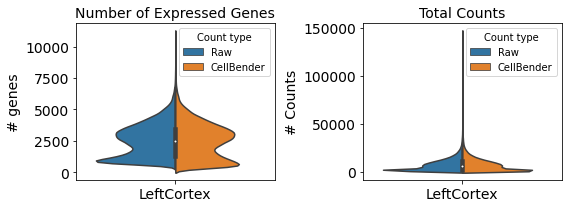

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assume adata.obs is the DataFrame you are working with
obs_data = adata.obs

if len(adata.obs['Tissue'].unique()) > 5:
    plot_category = "plate"
else:
    plot_category = "Tissue"
    

data_ngb = pd.melt(obs_data, id_vars=[plot_category], 
                   value_vars=['n_genes_by_counts_raw_counts', 'n_genes_by_counts_cb_counts'], 
                   var_name='Count type', value_name='counts')
data_ngb['Count type'] = data_ngb['Count type'].replace({
    'n_genes_by_counts_raw_counts': 'Raw',
    'n_genes_by_counts_cb_counts': 'CellBender'
})

data_tbc = pd.melt(obs_data, id_vars=[plot_category], 
                   value_vars=['total_counts_raw_counts', 'total_counts_cb_counts'], 
                   var_name='Count type', value_name='counts')
data_tbc['Count type'] = data_tbc['Count type'].replace({
    'total_counts_raw_counts': 'Raw',
    'total_counts_cb_counts': 'CellBender'
})


# Create the plots with independent y-axes
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=False)


size = 14

sns.violinplot(x=plot_category, y='counts', hue='Count type', data=data_ngb, split=True, ax=axes[0])
axes[0].set_title('Number of Expressed Genes', fontsize = size)
axes[0].set_ylabel('# genes', fontsize = size)
axes[0].set_xlabel("", fontsize = size)
axes[0].tick_params(axis='both', which='major', labelsize=size)

sns.violinplot(x=plot_category, y='counts', hue='Count type', data=data_tbc, split=True, ax=axes[1])
axes[1].set_title('Total Counts', fontsize = size)
axes[1].set_xlabel("", fontsize = size)
axes[1].set_ylabel('# Counts', fontsize = size)
axes[1].tick_params(axis='both', which='major', labelsize=size)

# Adjust layout
plt.tight_layout()



# Save the plot
qc_violin_genes_counts_filt = "qc_violin_plot1_plate_filt.png"
plt.savefig(qc_violin_genes_counts_filt, format='png', bbox_inches='tight', dpi=300)

plt.show()

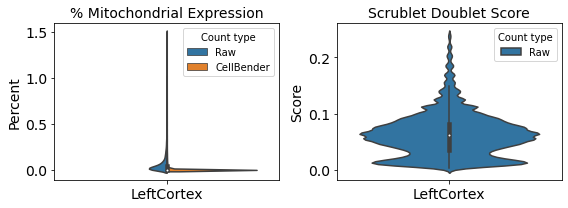

In [98]:

data_pmt = pd.melt(obs_data, id_vars=[plot_category], 
                   value_vars=['pct_counts_mt_raw_counts', 'pct_counts_mt_cb_counts'], 
                   var_name='Count type', value_name='Percent')
data_pmt['Count type'] = data_pmt['Count type'].replace({
    'pct_counts_mt_raw_counts': 'Raw',
    'pct_counts_mt_cb_counts': 'CellBender'
})


data_ds = pd.melt(obs_data, id_vars=[plot_category], 
                  value_vars=['doublet_score'], 
                  var_name='Count type', value_name='Score')
data_ds['Count type'] = data_ds['Count type'].replace({
    'doublet_score': 'Doublet Score'
})



    
# Create the plots with independent y-axes
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=False)


size = 14

sns.violinplot(x=plot_category, y='Percent', hue='Count type', data=data_pmt, split=True, ax=axes[0])
axes[0].set_title('% Mitochondrial Expression', fontsize = size)
axes[0].set_ylabel('Percent', fontsize = size)
axes[0].set_xlabel("", fontsize = size)
axes[0].tick_params(axis='both', which='major', labelsize=size)

sns.violinplot(x=plot_category, y='Score', data=data_ds, ax=axes[1])
axes[1].set_title('Scrublet Doublet Score', fontsize = size)
axes[1].set_ylabel('Score', fontsize = size)
axes[1].set_xlabel("", fontsize = size)
axes[1].tick_params(axis='both', which='major', labelsize=size)
axes[1].legend(title='Count type', labels=['Raw'])

# Adjust layout
plt.tight_layout()



# Save the plot
qc_violin_mt_ds_filt = "qc_violin_plot2_plate_filt.png"
plt.savefig(qc_violin_mt_ds_filt, format='png', bbox_inches='tight', dpi=300)

plt.show()

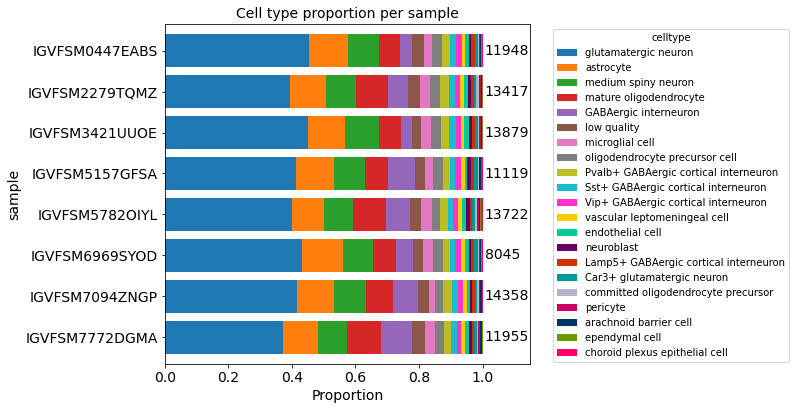

In [99]:
def stacked_barplot_proportions(adata, cluster_key, var_key, fsize=(12, 6), title=None, annotations=True, reverse_order=False, custom_order=None, custom_colors=None):
    colors = sns.color_palette("husl", n_colors=len(adata[var_key].unique()))

    # Group the data by 'cluster_key' and 'var_key', count occurrences, and calculate proportions
    grouped_data = adata.groupby([cluster_key, var_key]).size().unstack().fillna(0)
    proportions = grouped_data.div(grouped_data.sum(axis=1), axis=0)
    
    celltype_counts = adata[var_key].value_counts()
    ordered_celltypes = celltype_counts.index.tolist()

    # Group the data by 'cluster_key' and 'var_key', count occurrences, and calculate proportions
    grouped_data = adata.groupby([cluster_key, var_key]).size().unstack().fillna(0)
    proportions = grouped_data.div(grouped_data.sum(axis=1), axis=0)
    
    # Reorder the columns (cell types) based on the celltype counts
    proportions = proportions[ordered_celltypes]

    # Apply custom order if provided
    if custom_order:
        proportions = proportions.loc[custom_order]
    if custom_colors:
        colors = custom_colors

    # Reverse the order of the DataFrame if reverse_order is True
    if reverse_order:
        proportions = proportions.iloc[::-1]
        m = adata.groupby([cluster_key]).size().to_frame().iloc[::-1]
    else:
        m = adata.groupby([cluster_key]).size().to_frame()

    #sns.set_style('white')
    # Create the stacked bar plot
    ax = proportions.plot(kind='barh', color=colors, stacked=True, figsize=fsize, width=0.8, edgecolor=None)

    if annotations:
        for i, txt in enumerate(m[0]):
            ax.text(0.875, i, txt, fontsize=14, va='center', transform=ax.get_yaxis_transform())

    plt.xlim(0, 1.15)
    ax.tick_params(axis="x", labelsize=14)
    ax.tick_params(axis="y", labelsize=14)
    ax.set_xlabel("Proportion", fontsize=14)
    
    ax.set_ylabel(cluster_key)
    ax.set_ylabel("sample", fontsize=14)
    ax.set_title(title, fontsize=14)

    if annotations:
        ax.legend(title=var_key, bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.get_legend().remove()

    ax.grid(False)
    
    # Save the plot
    celltype_prop = "sample_celltype_proportions.png"
    plt.savefig(celltype_prop, format='png', bbox_inches='tight', dpi=300)

    plt.show()

custom_colors = [
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#d62728",  # Red
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17becf",  # Teal
    "#ff33cc",  # Magenta
    "#ffcc00",  # Gold
    "#00cc99",  # Turquoise
    "#660066",  # Dark Purple
    "#cc3300",  # Burnt Orange
    "#009999",  # Cyan
    "#b3b3cc",  # Lavender
    "#cc0066",  # Raspberry
    "#003366",  # Navy Blue
    "#669900",  # Olive Green
    "#ff0066"   # Hot Pink
]

stacked_barplot_proportions(adata.obs, cluster_key = 'IGVF_accession', 
                            fsize = (6.55,6.25),
                            custom_colors = custom_colors,
                            title = "Cell type proportion per sample",
                            var_key = 'celltype', reverse_order = True)


# PDF

In [100]:
from reportlab.lib import colors

elements = []

# Define the PDF filename
pdf_filename = f"{config.plate[0]}_report.pdf"
doc = SimpleDocTemplate(
    pdf_filename, 
    pagesize=letter,
    title=f"{config.plate[0]} Pipeline Report",  # Set the document title
)

# Define a style for the title
title_style = ParagraphStyle(
    name='TitleStyle',
    fontSize=20,
    textColor=colors.black,
    spaceAfter=20
)

# Define a style for the subtitle
subtitle_style = ParagraphStyle(
    name='SubtitleStyle',
    fontSize=16,
    textColor=colors.black,
    spaceAfter=10
)

# Define a style for the subtitle
subsubtitle_style = ParagraphStyle(
    name='SubtitleStyle',
    fontSize=12,
    textColor=HexColor('#666666'),
    spaceAfter=10
)


# Create the title paragraph and add it to elements
title = Paragraph(f"UCI/Caltech IGVF Dataset Pipeline Report", title_style)
elements.append(title)


elements.append(Spacer(1, 5))  

################################ broad overview ################################

expected_cells = "100,000" if kit == "WT" else "1,000,000"
genotypes = "\n".join(sample_df['Genotype'].unique().tolist())
tissues = "\n".join(sample_df['Tissue'].unique().tolist())
num_subpools = len(subpools)


# Create the data for the table
data = [
    ["", plate],
    ["Kit", kit],
    ["Chemistry", f"Parse {chemistry}"],
    ["Sample type", "Nuclei"],
    ["Genotypes", genotypes],
    ["Tissues", tissues],
    ["Subpools", num_subpools],
    ["Expected cells", expected_cells]
]

# Create the table with the data
df_table = Table(data)

# Set the table style
df_table.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
    ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
    ('BACKGROUND', (0, 1), (-1, -1), colors.white),
    ('GRID', (0, 0), (-1, -1), 1, colors.black),
    ('FONTNAME', (0, 1), (0, -1), 'Helvetica-Bold'),  # Make left column bold
    ('ALIGN', (0, 1), (0, -1), 'LEFT'),  # Align left column to the left
    ('FONTNAME', (1, 1), (-1, -1), 'Helvetica')  # Set the rest of the table to normal font
]))

# Add the table to elements
#elements.append(df_table)
#elements.append(Spacer(1, 10))  # Add spacing after the table


################################ Plate map ################################

# Add the resized plot image
plot_image = Image(plate_map)
plot_image.drawWidth = 325  # Adjust width in points
plot_image.drawHeight = 175  # Adjust height in points
plot_image.hAlign = 'LEFT'
#elements.append(plot_image)


# Define layout table for side-by-side placement
layout_data = [
    [df_table, plot_image]  # Place table and plot image side by side
]

# Create the layout table
layout_table = Table(layout_data, colWidths=[200, 325])  # Adjust widths as needed

# Set the layout table style
layout_table.setStyle(TableStyle([
    ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
    ('VALIGN', (0, 0), (-1, -1), 'MIDDLE'),
    ('GRID', (0, 0), (-1, -1), 1, colors.white)
]))

# Add the layout table to elements
elements.append(layout_table)


elements.append(Spacer(1, 10))  

################################################################ Header ################################################################

    
subtitle = Paragraph("I. Alignment", subtitle_style)
elements.append(subtitle)

elements.append(Spacer(1, 5))  

elements.append(Paragraph(f"A total of {formatted_total_reads_sum} reads were aligned using GENCODE vM32 with mm39 assembly.", ParagraphStyle(name='BodyText', fontSize=12, spaceAfter=12)))

elements.append(Spacer(1, 5))  

################################ Alignment stats ################################

    
subtitle_text = "Table 1: Pseudoalignment stats"  # Add your subtitle or label here
subtitle = Paragraph(subtitle_text, subsubtitle_style)
elements.append(subtitle)

data = [align_reports.columns.tolist()] + align_reports.values.tolist()
# Create the table with the data
df_table = Table(data)

# Set the table style
df_table.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
    ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
    ('BACKGROUND', (0, 1), (-1, -1), colors.white),
    ('GRID', (0, 0), (-1, -1), 1, colors.black)
]))

# Add the table to elements
elements.append(df_table)

elements.append(Spacer(1, 10))  



################################ subpool_knee ################################

# Add the resized plot image
plot_image = Image(subpool_knee)
plot_image.drawWidth = 375  # Adjust width in points
plot_image.drawHeight = 225  # Adjust height in points
plot_image.hAlign = 'CENTER'
elements.append(plot_image)

elements.append(Spacer(1, 20))  



################################################################ Header ################################################################

    
subtitle = Paragraph("II. Cell recovery", subtitle_style)
elements.append(subtitle)

elements.append(Spacer(1, 5))  




################################ QC stats 200 UMI ################################
  

dynamic_text = (
    f"A total of {formatted_cells_200umi_sum} cells have >=200 UMIs and {formatted_cells_500umi_sum} cells have >= 500 UMIs."
)
elements.append(Paragraph(dynamic_text, ParagraphStyle(name='BodyText', fontSize=12, spaceAfter=10)))


elements.append(Spacer(1, 5))  

subtitle_text = "Table 2: QC stats for cells >=200 UMI"

subtitle = Paragraph(subtitle_text, subsubtitle_style)
elements.append(subtitle)

data = [qc_200umi.columns.tolist()] + qc_200umi.values.tolist()
df_table = Table(data)

df_table.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
    ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
    ('BACKGROUND', (0, 1), (-1, -1), colors.white),
    ('GRID', (0, 0), (-1, -1), 1, colors.black)
]))

# Add the table to elements
elements.append(df_table)


elements.append(Spacer(1, 10))  


################################ QC stats 500 UMI ################################

subtitle_text = "Table 3: QC stats for cells >=500 UMI"

subtitle = Paragraph(subtitle_text, subsubtitle_style)
elements.append(subtitle)

# Convert the DataFrame to a list of lists with the column headers
data = [qc_500umi.columns.tolist()] + qc_500umi.values.tolist()

# Create the table with the data
df_table = Table(data)

# Set the table style
df_table.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
    ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
    ('BACKGROUND', (0, 1), (-1, -1), colors.white),
    ('GRID', (0, 0), (-1, -1), 1, colors.black)
]))

# Add the table to elements
elements.append(df_table)


elements.append(Spacer(1, 10))  

# ################################ hmaps ################################

elements.append(Paragraph("In this combinatorial barcoding assay, cells are barcoded in 96-well plates across 3 rounds.", ParagraphStyle(name='BodyText', fontSize=12, spaceAfter=10)))

elements.append(Spacer(1, 10))  


hmap_1 = "round_bc1_well_plate_hmap_all_subs.png"

# Add the resized plot image
plot_image = Image(hmap_1)
plot_image.drawWidth = 450  # Adjust width in points
plot_image.drawHeight = 250  # Adjust height in points
plot_image.hAlign = 'LEFT'
elements.append(plot_image)


hmap_2 = "round_bc2_well_plate_hmap_all_subs.png"

# Add the resized plot image
plot_image = Image(hmap_2)
plot_image.drawWidth = 450  # Adjust width in points
plot_image.drawHeight = 250  # Adjust height in points
plot_image.hAlign = 'LEFT'
elements.append(plot_image)


hmap_3 = "round_bc3_well_plate_hmap_all_subs.png"

# Add the resized plot image
plot_image = Image(hmap_3)
plot_image.drawWidth = 450  # Adjust width in points
plot_image.drawHeight = 250  # Adjust height in points
plot_image.hAlign = 'LEFT'
elements.append(plot_image)


elements.append(Spacer(1, 20))  


# ################################################################ Header ################################################################

    
subtitle = Paragraph("III. Background removal", subtitle_style)
elements.append(subtitle)

elements.append(Spacer(1, 5))  

elements.append(Paragraph("CellBender was run using 40,000 droplets included, default expected cells, and default learning rate per subpool.", ParagraphStyle(name='BodyText', fontSize=12, spaceAfter=10)))

elements.append(Spacer(1, 10)) 

subtitle_text = "Table 4: Cellbender stats"

subtitle = Paragraph(subtitle_text, subsubtitle_style)
elements.append(subtitle)

# Convert the DataFrame to a list of lists with the column headers
data = [final_cb_results.columns.tolist()] + final_cb_results.values.tolist()

# Create the table with the data
df_table = Table(data)

# Set the table style
df_table.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
    ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
    ('BACKGROUND', (0, 1), (-1, -1), colors.white),
    ('GRID', (0, 0), (-1, -1), 1, colors.black)
]))

# Add the table to elements
elements.append(df_table)


elements.append(Spacer(1, 10))  

# Add the resized plot image
plot_image = Image(cb_knee)
plot_image.drawWidth = 425  # Adjust width in points
plot_image.drawHeight = 225  # Adjust height in points
plot_image.hAlign = 'CENTER'
elements.append(plot_image)



elements.append(Spacer(1, 10))  

plot_image = Image(qc_violin_genes_counts)
plot_image.drawWidth = 380  # Adjust width in points
plot_image.drawHeight = 150  # Adjust height in points
plot_image.hAlign = 'CENTER'
elements.append(plot_image)

# Add the resized plot image
plot_image = Image(qc_violin_mt_ds)
plot_image.drawWidth = 380  # Adjust width in points
plot_image.drawHeight = 150  # Adjust height in points
plot_image.hAlign = 'CENTER'
elements.append(plot_image)


elements.append(Spacer(1, 60))  
elements.append(Spacer(1, 30))  

# ################################################################ Header ################################################################


subtitle = Paragraph("IV. Barcode sample map", subtitle_style)
elements.append(subtitle)

elements.append(Spacer(1, 10))  

style = ParagraphStyle(name='BodyText', fontSize=12, spaceAfter=12, leading=15)

# Create the paragraph with the updated style
elements.append(Paragraph(
    f"The first round corresponds to sample barcoding. In Parse Bio single-cell RNA-seq assays, two barcodes are included in the first round: a random hexamer (R) and oligo-dT (T) barcode per well*. This reduces 3-prime bias and allows for the capture of full-length transcripts. These barcodes can be found in the barcode-1 region in the seqspec. For the {kit} kit, samples are distributed across 48 wells in round 1. The following table includes our lab sample ID and IGVF sample accessions.",
    style
))

# Add the resized plot image
plot_image = Image(sample_plate_map)
plot_image.drawWidth = 375  # Adjust width in points
plot_image.drawHeight = 175  # Adjust height in points
plot_image.hAlign = 'CENTER'
elements.append(plot_image)

elements.append(Spacer(1, 10))  

acc_map_rename = acc_map
acc_map_rename.rename(columns={'parse_barcode_type': 'parse_barcode_type*'}, inplace=True)

data = [acc_map_rename.columns.tolist()] + acc_map_rename.values.tolist()
df_table = Table(data)

df_table.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
    ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
    ('BACKGROUND', (0, 1), (-1, -1), colors.white),
    ('GRID', (0, 0), (-1, -1), 1, colors.black)
]))

subtitle_text = "Table 5: Barcode sample map"

subtitle = Paragraph(subtitle_text, subsubtitle_style)
elements.append(subtitle)

# Add the table to elements
elements.append(df_table)

elements.append(Spacer(1, 15))  


# ################################################################ Header ################################################################


subtitle = Paragraph("V. Description of data processing workflow and associated file", subtitle_style)
elements.append(subtitle)

elements.append(Spacer(1, 10))  

style = ParagraphStyle(name='BodyText', fontSize=12, spaceAfter=12, leading=15)

# Create the paragraph with the updated style

elements.append(Paragraph(
    f"Data from all {len(subpools)} subpools were concatenated into one AnnData object. The AnnData contains detailed sample and cell metadata in the observation (obs) table and gene information in the variables table (var). Cell IDs (adata.obs.index) are re-formatted to be human-readable and unique across subpools and experiments by appending subpool and experiment IDs. This AnnData contains both raw and CellBender denoised counts matrices in separate layers: adata.layers['raw_counts'] and adata.layers['cellbender_counts']. The current adata.X points to the CellBender denoised counts. Cells are filtered by >0.5 cell_probability from CellBender analysis.",
    style
))

elements.append(Paragraph(
    f"In addition to CellBender filtering, cells were also filtered by the following QC parameters:",
    style
))


data = [
    ["min_counts", 500],
    ["max_counts", 150000],
    ["min_genes", 250],
    ["pct_counts_mt (max)", 1],
    ["doublet_score (max)", 0.25],
]

transposed_data = list(map(list, zip(*data)))

# Create the table with the data
df_table = Table(transposed_data)

# Set the table style
df_table.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
    ('ALIGN', (0, 0), (-1, -1), 'LEFT'),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
    ('BACKGROUND', (0, 1), (-1, -1), colors.white),
    ('GRID', (0, 0), (-1, -1), 1, colors.black),
    ('FONTNAME', (0, 1), (0, -1), 'Helvetica-Bold'),  # Make left column bold
    ('ALIGN', (0, 1), (0, -1), 'LEFT'),  # Align left column to the left
    ('FONTNAME', (1, 1), (-1, -1), 'Helvetica')  # Set the rest of the table to normal font
]))

elements.append(Spacer(1, 5)) 


subtitle_text = "Table 6: QC thresholds"

subtitle = Paragraph(subtitle_text, subsubtitle_style)
elements.append(subtitle)

# Add the table to elements
elements.append(df_table)

elements.append(Spacer(1, 15)) 


plot_image = Image(qc_violin_genes_counts_filt)
plot_image.drawWidth = 380  # Adjust width in points
plot_image.drawHeight = 125  # Adjust height in points
plot_image.hAlign = 'CENTER'
elements.append(plot_image)

# Add the resized plot image
plot_image = Image(qc_violin_mt_ds_filt)
plot_image.drawWidth = 380  # Adjust width in points
plot_image.drawHeight = 125  # Adjust height in points
plot_image.hAlign = 'CENTER'
elements.append(plot_image)

elements.append(Spacer(1, 15)) 


elements.append(Paragraph(
    f"After filtering, data was normalized and clustered using cellbender denoised counts. Normalization includes regression of technical parameters (number of genes expressed per cell and percent mitochondrial gene expression). Harmony was used to integrate exome capture and non-exome capture subpools for annotation. A Leiden clustering resolution of 2 was used for 55 total clusters. Additional sub-clustering was performed on one cluster (leiden #15) in order to separate Vip+ and Lamp5+ interneurons. Cell type annotations were assigned per Leiden cluster and two sub-clusters (leiden_R) using canonical cell type marker genes.",
    style
))


elements.append(Spacer(1, 10))  

celltype_prop = "sample_celltype_proportions.png"
plot_image = Image(celltype_prop)
plot_image.drawWidth = 450  # Adjust width in points
plot_image.drawHeight = 225  # Adjust height in points
plot_image.hAlign = 'CENTER'
elements.append(plot_image)


elements.append(Spacer(1, 5))  




data = [
    ["Key", "Description"],
    ["cellID", "Index of obs table. Includes barcoding wells for each round (1_2_3), subpool, and experiment."],
    ["lab_sample_id", "Human-readable sample name used in-house."],
    ["sample", "IGVF tissue accession."],
    ["plate", "Experiment ID, e.g. igvf_b01 (bridge experiment #1)."],
    ["subpool", "Subpool ID, e.g. Subpool_1. Number corresponds to Illumina index ID from Parse Bio kit."],
    ["SampleType", "Nuclei or Cells."],
    ["Tissue", "Human-readable tissue name, e.g. LeftCortex."],
    ["Sex", "Male or Female."],
    ["Age", "Age in postnatal months (PNM) of the mouse, e.g. PNM_02."],
    ["Genotype", "Mouse genotype/strain, e.g. B6J."],
    ["leiden", "Numeric Leiden cluster starting from 0."],
    ["leiden_R", "If necessary, Leiden clusters and any sub-clusters, e.g. 15_1."],
    ["subpool_type", "Exome capture (EX) or no exome capture (NO)."],
    ["general_celltype", "Broadest level of cell type annotations, e.g. neuron."],
    ["general_CL_ID", "EMBL CL database ID for general cell type annotation, e.g. CL:0000540."],
    ["celltype", "Finest level of cell type annotation with a CL ID, e.g. Vip+ GABAergic cortical interneuron."],
    ["CL_ID", "EMBL CL database ID for cell type annotation, CL:4023016"],
    ["subtype", "Finest level of cell type annotation that may not have a CL ID. Mostly matches celltype."],
    ["Protocol", "Cell barcoding and library building protocol/kit, e.g. Parse_WT."],
    ["Chemistry", "Protocol chemistry version, v2 or v3."],
    ["bc", "24-nucleotide sequence corresponding to 3 8-nucleotide barcode rounds (3, 2, 1)."],
    ["bc1_sequence", "8-nucleotide sequence barcode for round 1."],
    ["bc2_sequence", "8-nucleotide sequence barcode for round 2."],
    ["bc3_sequence", "8-nucleotide sequence barcode for round 3."],
    ["bc1_well", "Round 1 well."],
    ["bc2_well", "Round 2 well."],
    ["bc3_well", "Round 2 well."],
    ["Row", "Sample barcoding plate (round 1) row."],
    ["Column", "Sample barcoding plate (round 1) column."],
    ["well_type", "Single or Multiplexed."],
    ["Mouse_Tissue_ID", "Same as lab_sample_id."],
    ["DOB", "Date of birth of the mouse in month/day/year format."],
    ["Age_days", "Age of the mouse in days."],
    ["Body_weight_g", "Body weight in grams of the mouse."],
    ["Estrus_cycle", "Estimated estrus stage of the mouse, if applicable."],
    ["Dissection_date", "Date the tissue was harvested in month/day/year format."],
    ["Dissection_time", "Time in hours:minutes (24-hour time) the mouse was sacrificed."],
    ["ZT", "Number of hours into the light cycle, from lights on (06:30, ZT0) to lights off (20:30, ZT14)."],
    ["Dissector", "Initials of technician who dissected the tissue."],
    ["Tissue_weight_mg", "Tissue weight in milligrams."],
    ["Total_extracted_million", "Number of nuclei in millions extracted from the tissue."],
    ["Notes", "Notes taken during sample collection, experiment, or data processing."],
    ["n_genes_by_counts", "The number of genes with at least 1 count, calculated using raw counts."],
    ["total_counts", "Total counts (UMIs), calculated using raw counts."],
    ["total_counts_mt", "Total counts for mitochondrial genes, calculated using raw counts."],
    ["pct_counts_mt", "Percent of total counts in mitochondrial genes, calculated using raw counts."],
    ["doublet_score", "Scrublet doublet score, calculated using raw counts."],
    ["predicted_doublet", "Scrublet predicted doublet (True or False)."],
    ["background_fraction", "Fraction of counts CellBender predicted to be background noise."],
    ["cell_probability", "CellBender probability that the cell is real."],
    ["cell_size", "CellBender size factor."],
    ["droplet_efficiency", "CellBender statistic indicating transcript capture efficiency per cell."],
    
    
]



# Create the table with the data
df_table = Table(data)

# Set the table style
df_table.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
    ('ALIGN', (0, 0), (-1, -1), 'LEFT'),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
    ('BACKGROUND', (0, 1), (-1, -1), colors.white),
    ('GRID', (0, 0), (-1, -1), 1, colors.black),
    ('FONTNAME', (0, 1), (0, -1), 'Helvetica-Bold'),  # Make left column bold
    ('ALIGN', (0, 1), (0, -1), 'LEFT'),  # Align left column to the left
    ('FONTNAME', (1, 1), (-1, -1), 'Helvetica')  # Set the rest of the table to normal font
]))

subtitle_text = "Table 7: Description of obs keys in h5ad file"

subtitle = Paragraph(subtitle_text, subsubtitle_style)
elements.append(subtitle)

# Add the table to elements
elements.append(df_table)

elements.append(Spacer(1, 15)) 

# ################################################################ Header ################################################################


subtitle = Paragraph("VI. Package versions", subtitle_style)
elements.append(subtitle)

elements.append(Spacer(1, 10))  

# Create the data for the table
data = [
    ["package", "version"],
    ["kallisto", "0.50.1"],
    ["bustools", "0.43.2"],
    ["kb", "0.28.2"],
    ["Python", "3.9.0"],
    ["snakemake", "7.32.0"],
    ["cellbender", "0.3.2"],
    ["scanpy", "1.10.2"],
    ["scrublet", "0.2.3"],
    ["anndata", "0.10.8"],
    ["pandas", "2.2.2"],
    ["numpy", "1.26.4"],
    ["harmonypy", "0.0.9"]
]


# Create the table with the data
df_table = Table(data)

# Set the table style
df_table.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
    ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
    ('BACKGROUND', (0, 1), (-1, -1), colors.white),
    ('GRID', (0, 0), (-1, -1), 1, colors.black),
    ('FONTNAME', (0, 1), (0, -1), 'Helvetica-Bold'),  # Make left column bold
    ('ALIGN', (0, 1), (0, -1), 'LEFT'),  # Align left column to the left
    ('FONTNAME', (1, 1), (-1, -1), 'Helvetica')  # Set the rest of the table to normal font
]))

# Add the table to elements
elements.append(df_table)

elements.append(Spacer(1, 15)) 

# ################################################################ Header ################################################################


subtitle = Paragraph("VII. Contact information and GitHub", subtitle_style)
elements.append(subtitle)
elements.append(Spacer(1, 10)) 

elements.append(Paragraph("Ali Mortazavi, ali.mortazavi@uci.edu", ParagraphStyle(name='BodyText', fontSize=12, spaceAfter=10)))
elements.append(Paragraph("Elisabeth Rebboah, erebboah@uci.edu", ParagraphStyle(name='BodyText', fontSize=12, spaceAfter=10)))

pipeline_text = "Pipeline repo: "
pipeline_link = '<a href="https://github.com/mortazavilab/parse_pipeline" color="blue">https://github.com/mortazavilab/parse_pipeline</a>'

code_text = "Code used to make this report: "
code_link = '<a href="https://github.com/mortazavilab/parse_pipeline/blob/cellbender/annotation/Plate_Report.ipynb" color="blue">https://github.com/mortazavilab/parse_pipeline/blob/cellbender/annotation/Plate_Report.ipynb</a>'

analysis_text = "Code used to process and annotate the data: "
analysis_link = '<a href="https://github.com/mortazavilab/parse_pipeline/blob/cellbender/annotation/IGVFB01_LeftCortex_annotation.ipynb" color="blue">https://github.com/mortazavilab/parse_pipeline/blob/cellbender/annotation/IGVFB01_LeftCortex_annotation.ipynb</a>'


elements.append(Paragraph(pipeline_text + pipeline_link, ParagraphStyle(name='BodyText', fontSize=12, spaceAfter=10)))
elements.append(Paragraph(code_text + code_link, ParagraphStyle(name='BodyText', fontSize=12, spaceAfter=10)))
elements.append(Paragraph(analysis_text + analysis_link, ParagraphStyle(name='BodyText', fontSize=12, spaceAfter=10)))


In [101]:
# Build the PDF
doc.build(elements)
